In [20]:

import cv2, vpi
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

from torchvision.transforms.v2.functional import perspective
from torchvision.transforms import functional as F

(-0.5, 1919.5, 1199.5, -0.5)

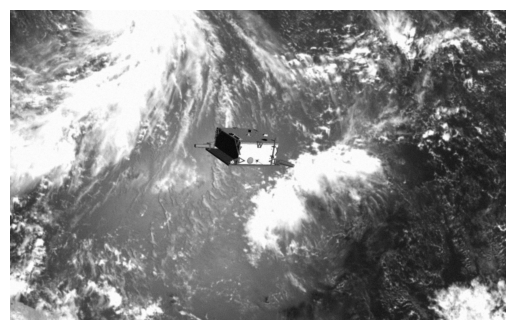

In [21]:
image_cv = cv2.imread('img008549.jpg')
# 用plotlib显示原图
plt.imshow(cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB))
plt.axis('off')

In [22]:
wrap_matrix = np.array([[1, 0, 1], [0, 1, 1], [0, 0, 1]], dtype=np.float32)

In [52]:
image_cv = cv2.imread('img008549.jpg')

In [53]:
image_cv = cv2.warpPerspective(image_cv, wrap_matrix, (image_cv.shape[1], image_cv.shape[0]))

In [54]:
%%timeit global image_cv
cv2.warpPerspective(image_cv, wrap_matrix, (image_cv.shape[1], image_cv.shape[0]))

2.24 ms ± 96.9 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


(-0.5, 1919.5, 1199.5, -0.5)

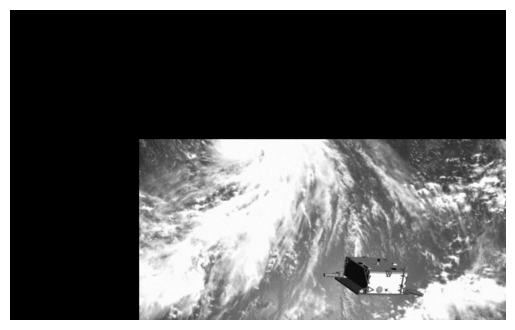

In [55]:
# 用plotlib显示原图
plt.imshow(cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB))
plt.axis('off')

In [90]:
backend = vpi.Backend.CUDA

In [91]:
image_cv = cv2.imread('img008549.jpg')

In [92]:
with vpi.Backend.CUDA:
    image_cv = vpi.asimage(image_cv).convert(vpi.Format.NV12_ER)

In [93]:
%%timeit global image_cv
with backend:
    image_cv = image_cv.perspwarp(wrap_matrix)

78.7 µs ± 605 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [88]:
with image_cv.rlock_cpu() as outData:
    image_cv = outData[0]

(-0.5, 1919.5, 1199.5, -0.5)

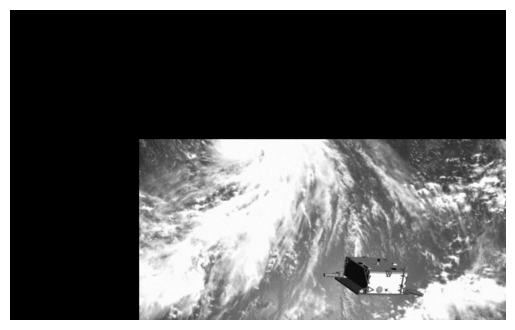

In [89]:
plt.imshow(cv2.cvtColor(image_cv, cv2.COLOR_GRAY2RGB))
plt.axis('off')